# In this notebook we're going to cover some of the most fundamental concepts of tensors using TensorFlow

More specifically, we're going  to cover:
* Introduction to tensors
* Getting information from tensors
* Manipulating tensors
* Tensors & NumPy
* Using @tf.function (a way to speed up your regular Python functions)
* Using GPUs with TensorFlow(or TPUs)
* Exercise to try for yourself

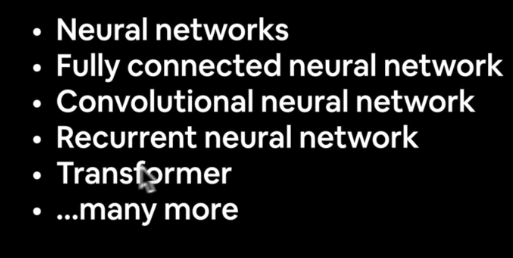

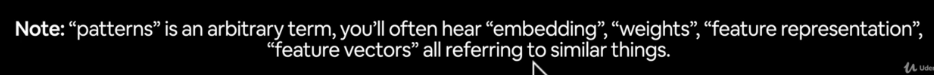

# Introduction to Tensors

In [ ]:
# Import TenserFlow
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# Create tensors with tf.constant()
scalar = tf.constant(7)
scalar

<tf.Tensor: shape=(), dtype=int32, numpy=7>

In [ ]:
# Check the number of dimensions of a tensor (ndim stands for number of dimensions)
scalar.ndim

0

In [ ]:
# Create a vector
vector = tf.constant([10, 10])
vector

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([10, 10], dtype=int32)>

In [ ]:
# Check the number of dimensions of a vector
vector.ndim

1

In [ ]:
# Create a matrix (has more than 1 dimension)
matrix = tf.constant([[10,7],
                      [7,10]])
matrix

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 7, 10]], dtype=int32)>

In [ ]:
# Check the number of dimensions of a matrix
matrix.ndim

2

In [ ]:
# Create another matrix using dtype parameter
another_matrix = tf.constant([[10.,7.],
                              [3.,2.],
                              [8.,9.]],dtype = tf.float16)
another_matrix

<tf.Tensor: shape=(3, 2), dtype=float16, numpy=
array([[10.,  7.],
       [ 3.,  2.],
       [ 8.,  9.]], dtype=float16)>

In [ ]:
# What's the number dimesnions of another_matrix?
another_matrix.ndim

2

In [ ]:
# Let's create a tensor
tensor = tf.constant([[[1,2,3],
                       [4,5,6]],
                      [[7,8,9],
                       [10,11,12]],
                      [[13,14,15],
                       [16,17,18]]])
tensor

<tf.Tensor: shape=(3, 2, 3), dtype=int32, numpy=
array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]],

       [[13, 14, 15],
        [16, 17, 18]]], dtype=int32)>

In [ ]:
tensor.ndim

3

What we've created so far:

* Scalar: a single number
* Vector: a number with direction (e.g wind speed and direction)
* Matrix: a 2-dimensional array of numbers
* Tensor: a n-dimensional array of numbers (where n can be any whole number)

<h1 style="color:red">lec 011:-Creating tensors with TensorFlow and tf.variable()</h1>

### Creating tensors wuth `tf.variable()`

In [ ]:
# Create the same tensor with tf.variable() as above
changeable_tensor=tf.Variable([[10,7],[7,10]])
unchangeable_tensor=tf.constant([[10,7],[7,10]])
changeable_tensor,unchangeable_tensor

(<tf.Variable 'Variable:0' shape=(2, 2) dtype=int32, numpy=
 array([[10,  7],
        [ 7, 10]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[10,  7],
        [ 7, 10]], dtype=int32)>)

In [ ]:
# Let's try change one of the elements in our changeable tensor
# changeable_tensor[0][0] = 7 # use var_name.assign(n), not this

In [ ]:
# How about we try .assign()
changeable_tensor[0].assign([7,2])
changeable_tensor

<tf.Variable 'Variable:0' shape=(2, 2) dtype=int32, numpy=
array([[ 7,  2],
       [ 7, 10]], dtype=int32)>

**Note:** Rarely in practice will you need to decide whether to use `tf.constant()` or `tf.Variable()` to create tensors, as TensorFlow does this for you. However, if in doubt, use `tf.constant()` and change it later if needed.
<hr>

Cause: `changeable_tensor[0][0]` is an **EagerTensor**, not a `tf.Variable`.
`.assign()` exists only on `tf.Variable`, not on tensors or tensor slices.

Key facts:

* `tf.Tensor` is immutable.
* Indexing a `tf.Variable` returns a **tensor view**, not a variable.
* You cannot assign to individual elements via indexing.

What works:

1. Assign to the **entire variable**:

```python
changeable_tensor.assign([[7, ...], [..., ...]])
```

2. Use `tf.tensor_scatter_nd_update` for element-wise updates:

```python
changeable_tensor.assign(
    tf.tensor_scatter_nd_update(
        changeable_tensor,
        indices=[[0, 0]],
        updates=[7]
    )
)
```

3. If you created it as a tensor instead of a variable, fix the root:

```python
changeable_tensor = tf.Variable(changeable_tensor)
```

Rule to remember:

* **Variables are mutable**
* **Tensors are not**
* **Slicing a variable destroys mutability**

This is TensorFlow design, not a bug.


<h1 style="color:red">lec 012:-Creating random tensors with TenserFlow</h1>

### Creating random tensors

Random tensors are tensors of some arbitary size which contain random numbers.

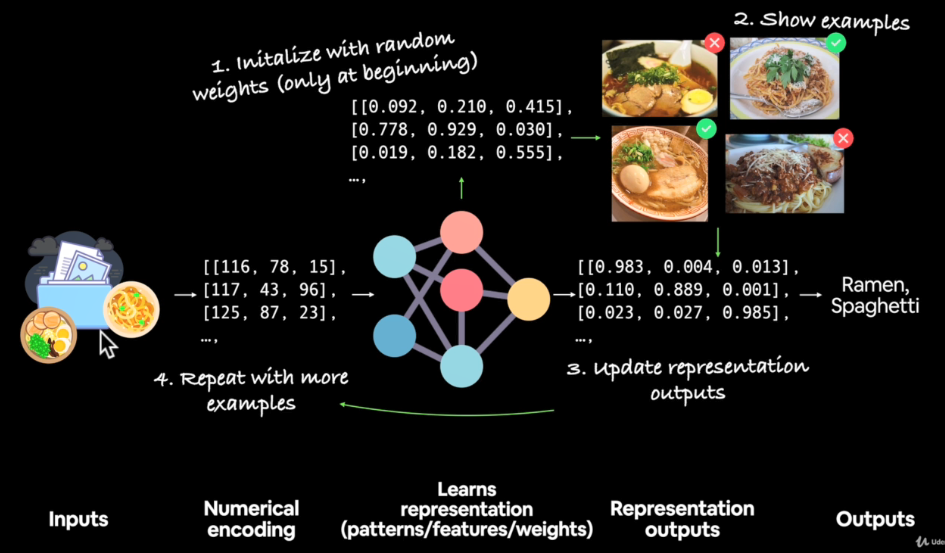

In [ ]:
# create two random (but the same) tensors
random_1 = tf.random.Generator.from_seed(42) # set seed for reproducibility
# random_1 = random_1.normal(shape=(3, 2)) # create tensor from a normal distribution
random_1

In [ ]:
# create two random (but the same) tensors
random_1 = tf.random.Generator.from_seed(42) # set seed for reproducibility
random_1 = random_1.normal(shape=(3, 2)) # create tensor from a normal distribution
random_1

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[-0.7565803 , -0.06854702],
       [ 0.07595026, -1.2573844 ],
       [-0.23193765, -1.8107855 ]], dtype=float32)>

In [ ]:
# create two random (but the same) tensors
random_2 = tf.random.Generator.from_seed(42) # set seed for reproducibility
random_2 = random_2.uniform(shape=(3, 2)) # create tensor from a uniform distribution
random_2

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0.7493447 , 0.73561966],
       [0.45230794, 0.49039817],
       [0.1889317 , 0.52027524]], dtype=float32)>

In [ ]:
# Create two random (but the same) tensors
random_1 = tf.random.Generator.from_seed(42) # set seed for probability
random_1 = random_1.normal(shape=(3, 2)) # create tensor from a normal distribution
random_2 = tf.random.Generator.from_seed(42)
random_2 = random_2.normal(shape=(3, 2))

# Are they equal?
random_1, random_2, random_1 == random_2

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193765, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193765, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=bool, numpy=
 array([[ True,  True],
        [ True,  True],
        [ True,  True]])>)

In TensorFlow, `tf.random.Generator` allows you to generate random numbers from multiple **distributions**. Here's a comprehensive list of the main ones you can use with `Generator`:

---

### 1. **Uniform Distributions**

* **Continuous uniform**: numbers between `[minval, maxval)`

```python
g = tf.random.Generator.from_seed(42)
g.uniform(shape=(3,2), minval=0, maxval=1)  # default: [0,1)
```

* **Integer uniform**: integers between `[minval, maxval)`

```python
g.uniform_int(shape=(3,2), minval=0, maxval=10)
```

---

### 2. **Normal (Gaussian) Distributions**

* **Standard normal** (mean=0, stddev=1)

```python
g.normal(shape=(3,2))
```

* **Truncated normal** (values more than 2 stddevs from mean are redrawn)

```python
g.truncated_normal(shape=(3,2), mean=0.0, stddev=1.0)
```

---

### 3. **Poisson Distribution**

* Integer values sampled from Poisson with rate `lam`

```python
g.poisson(shape=(3,2), lam=5.0)
```

---

### 4. **Gamma Distribution**

* Continuous positive values with shape `alpha` and scale `beta`

```python
g.gamma(shape=(3,2), alpha=1.0, beta=1.0)
```

---

### 5. **Other Distributions**

TensorFlow also has **standalone functions** in `tf.random` for distributions not directly exposed in the `Generator` API:

* Exponential: `tf.random.experimental.stateless_exponential`
* Beta: `tf.random.experimental.stateless_beta`
* LogNormal: `tf.random.experimental.stateless_lognormal`
* Categorical: `tf.random.categorical` (for sampling from probabilities)

---

If you want, I can make a **single ready-to-run snippet showing how to generate a tensor from every main distribution** using `tf.random.Generator`, so you can experiment directly. Do you want me to do that?


<h1 style="color:red">lec 013:-Shuffling the order of tensors</h1>

### Shuffle the order of elements in a tensor

In [ ]:
# Shuffle a tensor (valuable for when you want to shuffle your data so the inherent order doesn't effect learning)
not_shuffled = tf.constant([[10,7],
                            [3,4],
                            [2,5]])
# Shuffle our non-shuffled tensor (shape remains intact)
tf.random.shuffle(not_shuffled) # here it randomly shuffled the tensor accros first dimension (3,2) these 3 elements(rows) get shuffled

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 2,  5],
       [10,  7],
       [ 3,  4]], dtype=int32)>

In [ ]:
# Shuffle our non-shuffled tensor (shape remains intact)
tf.random.set_seed(42) # global level seed
tf.random.shuffle(not_shuffled,seed=42)  # operational level seed


<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4],
       [ 2,  5]], dtype=int32)>

In [ ]:
not_shuffled

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4],
       [ 2,  5]], dtype=int32)>

**Exercise:** Read through TensorFlow documentation on random seed generation:
https://www.tensorflow.org/api_docs/python/tf/random/set_seed

It looks like if we want our shuffled tensors to be in the same order, we've got to use the global level random seed and the operational level random seed:

> Rule 4: "If both the global and the operation seed are set: Both seeds are used in conjucation to determine the random sequence."

<h1 style="color:red">lec 014:-Creating tensors from NumPy arrays</h1>

### Other ways to make tensors

In [ ]:
# Create a tensor of all ones
tf.ones(shape=(3,4),dtype=tf.int32)

<tf.Tensor: shape=(3, 4), dtype=int32, numpy=
array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1]], dtype=int32)>

In [ ]:
# Create a tensor of all zeroes
tf.zeros(shape=[3,4])

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

### Turn NumPy arrays into tensors

The main difference between NumPy arrays and TenserFlow tensors is that tensors can be run on GPU (much faster for numerical computing).

In [ ]:
# You can also turn NumPy arrays into tensors
import numpy as np
numpy_A = np.arange(1,25,dtype=np.int32) # create a NumPy array between 1 and 25
numpy_A

# X = tf.constant(some_matrix) # var_name capital for matrix or tensor
# y = tf.constant(vector) # non-capital for vector


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)

In [ ]:
A = tf.constant(numpy_A)
A

<tf.Tensor: shape=(24,), dtype=int32, numpy=
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)>

In [ ]:
A = tf.constant(numpy_A,shape=(2,3,4))
A

<tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]],

       [[13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]]], dtype=int32)>

<h1 style="color:red">lec 015:-Getting information from your tensors (tensor attributes)</h1>

### Getting information from tensors

When dealing with tensors you probably want to be aware of the following attributes:

* Shape :- tensor.shape
* Rank :- tensor.ndim
* Axis or dimension :- tensor[0],tensor[:,1]
* Size :- tf.size(tensor)

In [ ]:
# Creates a rank 4 tensors (4 dimensions)
rank_4_tensor = tf.zeros(shape=[2,3,4,5])
rank_4_tensor

<tf.Tensor: shape=(2, 3, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
rank_4_tensor[0]

<tf.Tensor: shape=(3, 4, 5), dtype=float32, numpy=
array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], dtype=float32)>

In [ ]:
rank_4_tensor.shape,rank_4_tensor.ndim,tf.size(rank_4_tensor)

(TensorShape([2, 3, 4, 5]), 4, <tf.Tensor: shape=(), dtype=int32, numpy=120>)

In [ ]:
# Get various attributes of our tensor
print("Datatype of every element:", rank_4_tensor.dtype)
print("Number of dimensions (rank):", rank_4_tensor.ndim)
print("Shape of tensor:", rank_4_tensor.shape)
print("Elements along axis 0 of tensor:", rank_4_tensor.shape[0]) # shape[0] gives first element of shape (2,3,4,5)
print("Elements along last axis of tensor:", rank_4_tensor.shape[-1])
print("Total number of elements (2*3*4*5):", tf.size(rank_4_tensor))
print("Total number of elements (2*3*4*5):", tf.size(rank_4_tensor).numpy()) # for simple output convert datatype  to numpy

Datatype of every element: <dtype: 'float32'>
Number of dimensions (rank): 4
Shape of tensor: (2, 3, 4, 5)
Elements along axis 0 of tensor: 2
Elements along last axis of tensor: 5
Total number of elements (2*3*4*5): tf.Tensor(120, shape=(), dtype=int32)
Total number of elements (2*3*4*5): 120


<h1 style="color:red">lec 016:-Indexing and expanding tensors</h1>

## Indexing tensors

Tensors can be indexed just like Python lists.

In [ ]:
# Get the first 2 elements of each dimension
rank_4_tensor[:2,:2,:2,:2]

<tf.Tensor: shape=(2, 2, 2, 2), dtype=float32, numpy=
array([[[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]]], dtype=float32)>

In [ ]:
# Get the first element from each dimension from each index except for the final one
rank_4_tensor[:1,:1,:1,:] # masking all dim in shape except that ehich have semicolon only
rank_4_tensor[:1,:1,:1] # same as above this colon is not necessary

<tf.Tensor: shape=(1, 1, 1, 5), dtype=float32, numpy=array([[[[0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
# Create a rank 2 tensor (2 dimensions)
rank_2_tensor = tf.constant([[10,7],
                            [3,4]])

In [ ]:
# Get the last item of each of row of our rank 2 tensor
rank_2_tensor[:,-1]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([7, 4], dtype=int32)>

In [ ]:
# Add in extra dimension to our rank 2 tensor
rank_3_tensor = rank_2_tensor[...,tf.newaxis] # here ... is equal to :,:,:,: (no. of dimension times these)
rank_3_tensor # it add new dimension at the end of our tensor

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[10],
        [ 7]],

       [[ 3],
        [ 4]]], dtype=int32)>

In [ ]:
rank_4_tenso = rank_3_tensor[...,tf.newaxis] # here ... is equal to :,:,:,: (no. of dimension times these)
rank_4_tenso

<tf.Tensor: shape=(2, 2, 1, 1), dtype=int32, numpy=
array([[[[10]],

        [[ 7]]],


       [[[ 3]],

        [[ 4]]]], dtype=int32)>

In [ ]:
# Alternative to tf.newaxis
tf.expand_dims(rank_2_tensor,axis=-1) # -1 means expand the final axis

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[10],
        [ 7]],

       [[ 3],
        [ 4]]], dtype=int32)>

In [ ]:
tf.expand_dims(rank_2_tensor,axis=0) # expand the 0-axis

<tf.Tensor: shape=(1, 2, 2), dtype=int32, numpy=
array([[[10,  7],
        [ 3,  4]]], dtype=int32)>

In [ ]:
tf.expand_dims(rank_2_tensor,axis=1) # expand the 1-axis

<tf.Tensor: shape=(2, 1, 2), dtype=int32, numpy=
array([[[10,  7]],

       [[ 3,  4]]], dtype=int32)>

<h1 style="color:red">lec 017:-Manipulating tensors with basic operations</h1>

### Manipulating tensors (tensor operations)

**Basic operations**

`+`,`-`,`*`,`/`

In [ ]:
# You can add values to a tensor using the addition operator
tensor = tf.constant([[10,7],[3,4]])
tensor + 10 # original tensor is unchanged


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [ ]:
tensor = tensor+10 # we can also change .constant tensor values
tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [ ]:
# Multiplication also works
tensor*10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[200, 170],
       [130, 140]], dtype=int32)>

In [ ]:
# Substraction also works
tensor-10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4]], dtype=int32)>

In [ ]:
# We can use the tensorflow built-in function too
tf.multiply(tensor,10) # this is faster then tensor*10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[200, 170],
       [130, 140]], dtype=int32)>

In [ ]:
tensor # tensor remains unchanged

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [ ]:
print(tf.add(tensor,10))
print(tf.subtract(tensor,10))
print(tf.divide(tensor,10))

tf.Tensor(
[[30 27]
 [23 24]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[10  7]
 [ 3  4]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[2.  1.7]
 [1.3 1.4]], shape=(2, 2), dtype=float64)


“Multiply rank-3 tensors” is ambiguous. The result depends on **which indices you want to contract or align**. A rank-3 tensor has shape `(a, b, c)`. Below are the **standard, well-defined ways** to multiply them.

---

## 1. Element-wise multiplication (Hadamard product)

**No index contraction. Shapes must match.**

**Math**
[
C_{ijk} = A_{ijk} \cdot B_{ijk}
]

**Shape**

```
A: (a, b, c)
B: (a, b, c)
C: (a, b, c)
```

**NumPy**

```python
C = A * B
```

**TensorFlow**

```python
C = tf.multiply(A, B)
```

---

## 2. Tensor contraction (generalized dot product)

You **sum over one or more shared axes**.

### Example: contract last axis of A with first axis of B

**Math**
[
C_{ijmn} = \sum_k A_{ijk} B_{kmn}
]

**Shapes**

```
A: (i, j, k)
B: (k, m, n)
C: (i, j, m, n)
```

**NumPy (recommended)**

```python
C = np.tensordot(A, B, axes=([2], [0]))
```

**TensorFlow**

```python
C = tf.tensordot(A, B, axes=[[2], [0]])
```

---

## 3. Batched matrix multiplication (most common in ML)

Treat one axis as **batch**, multiply matrices inside each batch.

### Example: batch dimension = 0

**Shapes**

```
A: (batch, m, k)
B: (batch, k, n)
C: (batch, m, n)
```

**NumPy**

```python
C = np.matmul(A, B)
```

**TensorFlow**

```python
C = tf.matmul(A, B)
```

This is what happens in:

* attention mechanisms
* CNN feature maps
* transformer projections

---

## 4. Einstein summation (most explicit and powerful)

You **write the index math directly**.

### Example: same as tensordot above

```python
C = np.einsum('ijk,kmn->ijmn', A, B)
```

### Batch matmul

```python
C = np.einsum('bmk,bkn->bmn', A, B)
```

TensorFlow:

```python
C = tf.einsum('bmk,bkn->bmn', A, B)
```

This is the **cleanest** way when tensors get complex.

---

## 5. Outer product of two rank-3 tensors

**No summation, dimensions expand.**

**Shapes**

```
A: (a, b, c)
B: (d, e, f)
C: (a, b, c, d, e, f)
```

**NumPy**

```python
C = np.tensordot(A, B, axes=0)
```

---

## Mental model (important)

* **Rank = number of indices**
* **Multiplication = choose which indices to sum over**
* If you don’t specify axes → element-wise
* If you specify axes → contraction
* If one axis is batch → batched matmul

---

If you give **exact shapes** and **what you want mathematically**, the multiplication becomes unambiguous.


<h1 style="color:red">lec 018:-Matrix multiplication with tensors part 1</h1>

**Matrix multiplication**

In machine learning, matrix multiplication is one of the most common tensor operations.

There are two rules our tensors (or matrices) need to fulfil if we're going to matrix multiply them:

1. The inner dimensions must match
2. The resulting matrix has the shape of the inner dimensions

In [ ]:
# Matrix multiplication in tensorflow
print(tensor) # tensor*tensor it is element-wise
tf.matmul(tensor,tensor)

tf.Tensor(
[[20 17]
 [13 14]], shape=(2, 2), dtype=int32)


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[621, 578],
       [442, 417]], dtype=int32)>

In [ ]:
# Matrix multiplication with python operator "@"
tensor @ tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[621, 578],
       [442, 417]], dtype=int32)>

In [ ]:
# Create a tensor (3,2) shape
X = tf.constant([[1,2],
                [3,4],
                [5,6]])
# Create another (3,2) tensor
Y = tf.constant([[7,8],
                 [9,10],
                 [11,12]])

In [ ]:
# X @ Y # throws an error matrix shape incompatible
# tf.matmul(X,Y) # throws an error matrix shape incompatible

**Resource:** Info and example of matrix multiplication: https://www.mathsisfun.com/algebra/matrix-multiplication.html

In [ ]:
print(X @ tf.transpose(Y))
print(tf.matmul(Y,tf.transpose(X)))

tf.Tensor(
[[ 23  29  35]
 [ 53  67  81]
 [ 83 105 127]], shape=(3, 3), dtype=int32)
tf.Tensor(
[[ 23  53  83]
 [ 29  67 105]
 [ 35  81 127]], shape=(3, 3), dtype=int32)


<h1 style="color:red">lec 019:-Matrix multiplication with tensors part 2</h1>

Reshaping **does not change values**. It only changes **how the same linear sequence is indexed**. Elements are reassigned **in row-major order (C order)** unless specified otherwise.

---

## Given

Tensor with **16 elements**
Original shape: **(4, 4)**
New shape: **(2, 4, 2)**
Total elements check:
(4×4 = 16) and (2×4×2 = 16) ✔

---

## Step 1: Original tensor (4×4)

Assume values 1 to 16 filled row-wise:

```
A =
[[ 1,  2,  3,  4],
 [ 5,  6,  7,  8],
 [ 9, 10, 11, 12],
 [13, 14, 15, 16]]
```

Linear (flattened) order in memory:

```
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
```

---

## Step 2: Reshape to (2, 4, 2)

Now we **refill this sequence** into the new shape **in order**.

Shape meaning:

* 2 blocks
* each block has 4 rows
* each row has 2 elements

### Result:

```
B =
[
  [ [ 1,  2],
    [ 3,  4],
    [ 5,  6],
    [ 7,  8] ],

  [ [ 9, 10],
    [11, 12],
    [13, 14],
    [15, 16] ]
]
```

---

## Exact element mapping

| Original A[i][j] | Linear index | New B[x][y][z] |
| ---------------- | ------------ | -------------- |
| A[0][0] = 1      | 0            | B[0][0][0]     |
| A[0][1] = 2      | 1            | B[0][0][1]     |
| A[0][2] = 3      | 2            | B[0][1][0]     |
| A[0][3] = 4      | 3            | B[0][1][1]     |
| A[1][0] = 5      | 4            | B[0][2][0]     |
| A[1][1] = 6      | 5            | B[0][2][1]     |
| A[1][2] = 7      | 6            | B[0][3][0]     |
| A[1][3] = 8      | 7            | B[0][3][1]     |
| A[2][0] = 9      | 8            | B[1][0][0]     |
| A[2][1] =10      | 9            | B[1][0][1]     |
| A[2][2] =11      | 10           | B[1][1][0]     |
| A[2][3] =12      | 11           | B[1][1][1]     |
| A[3][0] =13      | 12           | B[1][2][0]     |
| A[3][1] =14      | 13           | B[1][2][1]     |
| A[3][2] =15      | 14           | B[1][3][0]     |
| A[3][3] =16      | 15           | B[1][3][1]     |

---

## Code example

### NumPy

```python
import numpy as np

A = np.arange(1, 17).reshape(4, 4)
B = A.reshape(2, 4, 2)

print(A)
print(B)
```

### TensorFlow

```python
import tensorflow as tf

A = tf.reshape(tf.range(1, 17), (4, 4))
B = tf.reshape(A, (2, 4, 2))
```

---

## Key rules (non-negotiable)

1. **Total elements must match**
2. **Order is preserved**
3. Reshape is **view-level**, not computation
4. No learning, no math, no mixing — just reindexing

If you want column-wise behavior, that is a **different memory order**, not default reshape.


In [ ]:
# Let's change the shape of Y
tf.reshape(Y,shape=(2,3))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 7,  8,  9],
       [10, 11, 12]], dtype=int32)>

In [ ]:
# Try to mat mul X by reshaped Y
X @ tf.reshape(Y,shape=(2,3))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

In [ ]:
# Try to mat mul Y by reshaped X
tf.reshape(X,shape=(2,3)) @ Y

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 58,  64],
       [139, 154]], dtype=int32)>

In [ ]:
# can do same with transpose
tf.transpose(X) , tf.reshape(X,shape=(2,3))

(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 3, 5],
        [2, 4, 6]], dtype=int32)>,
 <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 2, 3],
        [4, 5, 6]], dtype=int32)>)

<h1 style="color:red">lec 020:-Matrix multiplication with tensors part 3</h1>

**The dot product**

Matrix multiplication is also referred to as the dot product.

You can perform matrix multiplication using:
* `tf.matmul()`
* `tf.tensordot()`

In [ ]:
# Perform the dot product using X and Y (required X or Y to be transposed)
tf.tensordot(tf.transpose(X),Y,axes=1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

In [ ]:
# Perform multipplication between X and Y (reshaped)
tf.matmul(X,tf.reshape(Y,shape=(2,3)))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

In [ ]:
# Check the values of Y,reshape Y and transpoded Y
print("Normal Y:")
print(Y,"\n")

print("Y reshaped to (2,3):")
print(tf.reshape(Y,shape=(2,3)),"\n")

print("Y transposed:")
print(tf.transpose(Y))

Normal Y:
tf.Tensor(
[[ 7  8]
 [ 9 10]
 [11 12]], shape=(3, 2), dtype=int32) 

Y reshaped to (2,3):
tf.Tensor(
[[ 7  8  9]
 [10 11 12]], shape=(2, 3), dtype=int32) 

Y transposed:
tf.Tensor(
[[ 7  9 11]
 [ 8 10 12]], shape=(2, 3), dtype=int32)


Generally, when performing **matrix multiplication on two tensors and one of the axes doesn't line up**, you will transpose (rather than reshape) one of the tensors to get satisfy the matrix multiplication rules.

<h1 style="color:red">lec 021:-Changing the datatype of  tensors</h1>

In [ ]:
# Create a new tensor with default datatype (float32),(int32),(string)
B = tf.constant([1.7,7.4])
B.dtype

tf.float32

In [ ]:
C = tf.constant([7,10])
C.dtype

tf.int32

In [ ]:
D = tf.constant(["1","2"])
D.dtype

tf.string

In [ ]:
# Change float32 to float16 (reduce the precision for memory and speed)
B = tf.cast(B,dtype=tf.float16)
B.dtype

tf.float16

In [ ]:
# Change from int32 to float32
E = tf.cast(C,dtype=tf.float32)
E.dtype

tf.float32

In [ ]:
E_float16 = tf.cast(E,dtype=tf.float16)
E_float16.dtype

tf.float16

<h1 style="color:red">lec 022:-Tensor aggregating (finding the min, max, mean, & more)</h1>

### Aggregating  tensors

Aggregating tensors = condensing them from multiple values down to a smaller amount of values

In [ ]:
# Get the absolute values
D = tf.constant([-7,-10])
D

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ -7, -10], dtype=int32)>

In [ ]:
# Get the absolute values
tf.abs(D)

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 7, 10], dtype=int32)>

Let's go through the following forms of aggregation:
* Get the minimum
* Get the maximum
* Get the mean of a tensor
* Get the sum of a tensor

In [ ]:
# Create a random tensor with values between 0 and 100 of size 50
E = tf.constant(np.random.randint(0,100,size=50))
E

<tf.Tensor: shape=(50,), dtype=int64, numpy=
array([14, 35, 24, 31, 89, 14, 56, 28,  7, 88, 30, 49, 12, 34, 98, 54, 69,
       91, 94, 21,  7, 21, 61, 90, 68, 92, 34, 75, 16, 66, 75, 74, 52, 75,
       72, 26, 86, 23,  5, 59, 77, 85, 93, 44, 37, 89, 46,  0, 70, 85])>

In [ ]:
tf.size(E), E.shape, E.ndim

(<tf.Tensor: shape=(), dtype=int32, numpy=50>, TensorShape([50]), 1)

In [ ]:
# Find the minimum
tf.reduce_min(E)

<tf.Tensor: shape=(), dtype=int64, numpy=0>

In [ ]:
# Find the maximum, mean, sum, product
print(tf.reduce_max(E))
print(tf.reduce_mean(E))
print(tf.reduce_sum(E))
print(tf.reduce_prod(E))
# print(tf.reduce_std(E)) error not any std function
# print(tf.reduce_all(E)) must be bool tensor not int64

tf.Tensor(98, shape=(), dtype=int64)
tf.Tensor(52, shape=(), dtype=int64)
tf.Tensor(2641, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)


**Exercise:** With what we've just learned, find the variance and standard deviation of our `E` tensor using TensorFlow methods.

In [ ]:
# Standard deviation
tf.math.reduce_std(tf.cast(E, dtype=tf.float32))

<tf.Tensor: shape=(), dtype=float32, numpy=29.50029754638672>

In [ ]:
# variance
tf.math.reduce_variance(tf.cast(E, dtype=tf.float32))

<tf.Tensor: shape=(), dtype=float32, numpy=870.267578125>

In [ ]:
# variance
abs_tf = tf.abs(tf.cast(E, dtype=tf.float32)-tf.reduce_mean(tf.cast(E, dtype=tf.float32)))
tf.reduce_sum(tf.square(abs_tf))/tf.cast(tf.size(E),dtype=tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=870.267578125>

In [ ]:
# standard deviation
tf.sqrt(tf.reduce_sum(tf.square(abs_tf))/tf.cast(tf.size(E),dtype=tf.float32))

<tf.Tensor: shape=(), dtype=float32, numpy=29.50029754638672>

**Standard deviation** measures how far values typically spread from the **mean**.

---

## Definition

For values (x_1, x_2, \dots, x_n):

[
\mu = \frac{1}{n}\sum x_i
]

[
\sigma = \sqrt{\frac{1}{n}\sum (x_i - \mu)^2}
]

It is the **square root of variance**.

---

## What it tells you

* Small σ → values are tightly clustered around the mean
* Large σ → values are widely spread
* Units are the **same as the data** (unlike variance)

---

## Simple example

Data:

```
[2, 4, 4, 4, 5, 5, 7, 9]
```

Mean:

```
μ = 5
```

Squared deviations:

```
(2−5)² = 9
(4−5)² = 1
(4−5)² = 1
(4−5)² = 1
(5−5)² = 0
(5−5)² = 0
(7−5)² = 4
(9−5)² = 16
```

Variance:

```
(9+1+1+1+0+0+4+16) / 8 = 4
```

Standard deviation:

```
σ = √4 = 2
```

---

## Population vs sample

* **Population SD**: divide by **n**
* **Sample SD**: divide by **n−1** (Bessel correction)

Machine learning usually uses **population SD**.

---

## In TensorFlow

```
mean = tf.reduce_mean(x)
std  = tf.sqrt(tf.reduce_mean(tf.square(x - mean)))
```

---

## Why it matters in ML

* Feature scaling (standardization / z-score)
* Stabilizes gradient descent
* Makes features comparable

Standard deviation quantifies **uncertainty and dispersion**, not accuracy.


<h1 style="color:red">lec 023:</h1>

In [ ]:
# To find the variance of our tensor, we need acces to tensorflow_proabability
import tensorflow_probability as tfp
tfp.stats.variance(E)

<tf.Tensor: shape=(), dtype=int64, numpy=870>

In [ ]:
# Find the standard deviation
# tf.math.reduce_std(E) # Doesn't work try making all the values float
tf.math.reduce_std(tf.cast(E,dtype=tf.float32))

<tf.Tensor: shape=(), dtype=float32, numpy=29.50029754638672>

**Note:** for whole tenserflow generally float32 is general type

<h1 style="color:red">lec 024:-Finding the positional minimum and maximum of a tensor (argmin and argmax)</h1>

### FInd the positional maximum and minimum

In [ ]:
# Create a new tensor for finding positional minimun and maximum
tf.random.set_seed(42)
F = tf.random.uniform(shape=[50])
F

<tf.Tensor: shape=(50,), dtype=float32, numpy=
array([0.6645621 , 0.44100678, 0.3528825 , 0.46448255, 0.03366041,
       0.68467236, 0.74011743, 0.8724445 , 0.22632635, 0.22319686,
       0.3103881 , 0.7223358 , 0.13318717, 0.5480639 , 0.5746088 ,
       0.8996835 , 0.00946367, 0.5212307 , 0.6345445 , 0.1993283 ,
       0.72942245, 0.54583454, 0.10756552, 0.6767061 , 0.6602763 ,
       0.33695042, 0.60141766, 0.21062577, 0.8527372 , 0.44062173,
       0.9485276 , 0.23752594, 0.81179297, 0.5263394 , 0.494308  ,
       0.21612847, 0.8457197 , 0.8718841 , 0.3083862 , 0.6868038 ,
       0.23764038, 0.7817228 , 0.9671384 , 0.06870162, 0.79873943,
       0.66028714, 0.5871513 , 0.16461694, 0.7381023 , 0.32054043],
      dtype=float32)>

In [ ]:
# Find the positional maximum
tf.argmax(F)

<tf.Tensor: shape=(), dtype=int64, numpy=42>

In [ ]:
# Index on our largest value position
tf.reduce_max(F)

<tf.Tensor: shape=(), dtype=float32, numpy=0.967138409614563>

In [ ]:
tf.argsort(F) # same as numpy argsort

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([16,  4, 43, 22, 12, 47, 19, 27, 35,  9,  8, 31, 40, 38, 10, 49, 25,
        2, 29,  1,  3, 34, 17, 33, 21, 13, 14, 46, 26, 18, 24, 45,  0, 23,
        5, 39, 11, 20, 48,  6, 41, 44, 32, 36, 28, 37,  7, 15, 30, 42],
      dtype=int32)>

In [ ]:
# Check for equality
F[tf.argmax(F)] == tf.reduce_max(F)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [ ]:
tf.argmin(F)

<tf.Tensor: shape=(), dtype=int64, numpy=16>

In [ ]:
F[tf.argmin(F)]

<tf.Tensor: shape=(), dtype=float32, numpy=0.009463667869567871>

<h1 style="color:red">lec 025:-Squeezing a tensor (removing all 1-dimension axes)</h1>

### Squeezing a tensor (removing all single dimensions)

In [ ]:
# Create a tensor to get started
tf.random.set_seed(42)
G = tf.constant(tf.random.uniform(shape=[50]),shape =(1,1,1,1,50))
G

<tf.Tensor: shape=(1, 1, 1, 1, 50), dtype=float32, numpy=
array([[[[[0.6645621 , 0.44100678, 0.3528825 , 0.46448255, 0.03366041,
           0.68467236, 0.74011743, 0.8724445 , 0.22632635, 0.22319686,
           0.3103881 , 0.7223358 , 0.13318717, 0.5480639 , 0.5746088 ,
           0.8996835 , 0.00946367, 0.5212307 , 0.6345445 , 0.1993283 ,
           0.72942245, 0.54583454, 0.10756552, 0.6767061 , 0.6602763 ,
           0.33695042, 0.60141766, 0.21062577, 0.8527372 , 0.44062173,
           0.9485276 , 0.23752594, 0.81179297, 0.5263394 , 0.494308  ,
           0.21612847, 0.8457197 , 0.8718841 , 0.3083862 , 0.6868038 ,
           0.23764038, 0.7817228 , 0.9671384 , 0.06870162, 0.79873943,
           0.66028714, 0.5871513 , 0.16461694, 0.7381023 , 0.32054043]]]]],
      dtype=float32)>

In [ ]:
G.shape

TensorShape([1, 1, 1, 1, 50])

In [ ]:
G_squeezed = tf.squeeze(G)
G_squeezed, G_squeezed.shape

(<tf.Tensor: shape=(50,), dtype=float32, numpy=
 array([0.6645621 , 0.44100678, 0.3528825 , 0.46448255, 0.03366041,
        0.68467236, 0.74011743, 0.8724445 , 0.22632635, 0.22319686,
        0.3103881 , 0.7223358 , 0.13318717, 0.5480639 , 0.5746088 ,
        0.8996835 , 0.00946367, 0.5212307 , 0.6345445 , 0.1993283 ,
        0.72942245, 0.54583454, 0.10756552, 0.6767061 , 0.6602763 ,
        0.33695042, 0.60141766, 0.21062577, 0.8527372 , 0.44062173,
        0.9485276 , 0.23752594, 0.81179297, 0.5263394 , 0.494308  ,
        0.21612847, 0.8457197 , 0.8718841 , 0.3083862 , 0.6868038 ,
        0.23764038, 0.7817228 , 0.9671384 , 0.06870162, 0.79873943,
        0.66028714, 0.5871513 , 0.16461694, 0.7381023 , 0.32054043],
       dtype=float32)>,
 TensorShape([50]))

<h1 style="color:red">lec 026:-One-hot encoding tensors</h1>

### One-hot encoding tensors

In [ ]:
# Create a list of indices
some_list = [0,1,2,3] # could be red, green, blue, purple

# One hot encode our list of indices
tf.one_hot(some_list,depth=4) # ouput is equal to depth*depth


<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)>

In [ ]:
tf.one_hot(some_list,depth=3) # removed column related to another value completely

<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.]], dtype=float32)>

In [ ]:
# Specify custom values for one hot encoding
tf.one_hot(some_list,depth=4,on_value="yo I love deep learning",off_value="I also like to dance")

<tf.Tensor: shape=(4, 4), dtype=string, numpy=
array([[b'yo I love deep learning', b'I also like to dance',
        b'I also like to dance', b'I also like to dance'],
       [b'I also like to dance', b'yo I love deep learning',
        b'I also like to dance', b'I also like to dance'],
       [b'I also like to dance', b'I also like to dance',
        b'yo I love deep learning', b'I also like to dance'],
       [b'I also like to dance', b'I also like to dance',
        b'I also like to dance', b'yo I love deep learning']],
      dtype=object)>

<h1 style="color:red">lec 027:-Trying out more tensor math operations</h1>

### Squaring, log, square root

In [ ]:
# Create a new tensor
H = tf.range(1,10)
H

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [ ]:
# Square it
tf.square(H)

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 1,  4,  9, 16, 25, 36, 49, 64, 81], dtype=int32)>

In [ ]:
# Find the squareroot
tf.sqrt(tf.cast(H,dtype=tf.float32))

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([1.       , 1.4142135, 1.7320508, 2.       , 2.2360678, 2.4494896,
       2.6457512, 2.828427 , 3.       ], dtype=float32)>

In [ ]:
# Find the log
tf.math.log(tf.cast(H,dtype=tf.float32))


<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([0.       , 0.6931472, 1.0986123, 1.3862944, 1.609438 , 1.7917595,
       1.9459102, 2.0794415, 2.1972246], dtype=float32)>

<h1 style="color:red">lec 028:-Exploring TensorFlow and NumPy's compatibility</h1>

### Tensors and NumPy

TensorFlow interacts beautifully with NumPy arrays

In [ ]:
# Create a tensor directly from a NumPy array
J = tf.constant(np.array([3.,7.,10.]))
J

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 3.,  7., 10.])>

In [ ]:
# Convert or tensor back to NumPy array
np.array(J), type(np.array(J))

(array([ 3.,  7., 10.]), numpy.ndarray)

In [ ]:
# Convert tensor J to  a Numpy array
J.numpy(), type(J.numpy())

(array([ 3.,  7., 10.]), numpy.ndarray)

In [ ]:
# The default types of each are slightly different
numpy_J = tf.constant(np.array([3.,7.,10.]))
tensor_J = tf.constant([3.,7.,10.])

# Check the datatypes of each (for numpy it is float64 for tensor it is float32)
numpy_J.dtype, tensor_J.dtype

(tf.float64, tf.float32)

<h1 style="color:red">lec 029:-Making sure our tensor operations run really fast on GPUs</h1>

### Finding access to GPUs

In [ ]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# tf.config.list_physical_devices("cpu") # letter must remain capital case sensitive
tf.config.list_physical_devices("CPU")

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [ ]:
!nvidia-smi # for checking GPU type

Thu Dec 25 20:48:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             28W /   70W |     106MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Note:** If you have access to CUDA-enabled GPU, TensorFlow will automatically use it whenever possible.


                from IPython.display import display, HTML

html_code = """
<!DOCTYPE html>
<html>
<head>
<link href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/css/bootstrap.min.css"
      rel="stylesheet"
      integrity="sha384-BVYiiSIFeK1dGmJRAkycuHAHRg32OmUcww7on3RYdg4Va+PmSTsz/K68vbdEjh4u"
      crossorigin="anonymous">
<title>030 TensorFlow Fundamentals challenge, exercises & extra-curriculum</title>
</head>

<body>
<div class="container">
  <div class="row">
    <div class="col-md-10 col-md-offset-1">
      <p class="lead">
        <p>Massive effort on making it through the first section!</p>
        <p>By now you should have a high-level overview of what deep learning and neural networks are and what kind of problems they can be used for.</p>
        <p>And you should also be familiar with creating and manipulating tensors in TensorFlow. Because as you'll see later on, tensors are a fundamental component of representing and finding patterns in data.</p>
        <p>Before moving onto the next section, it's time to practice your skills!</p>
        <p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" target="_blank">course GitHub repo</a> under “course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p>
        <p>By going through these, you'll cement your foundational knowledge of deep learning and TensorFlow and be ready to start building neural networks of your own.</p>
        <p>See the link below for more.</p>
        <ul>
          <li>
            <p>
              <a href="https://github.com/mrdbourke/tensorflow-deep-learning#-00-tensorflow-fundamentals-exercises" target="_blank">
                TensorFlow and Deep Learning Fundamentals Exercises & Extra-curriculum
              </a>
            </p>
          </li>
        </ul>
        <p>And remember, if you have any questions, be sure to
          <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" target="_blank">
            add them to the discussions page
          </a>.
        </p>
        <p><strong>Challenge:</strong> What are 3 of your favourite use cases for deep learning?</p>
        <p>Send a message with your answer(s) to the #machinelearning-datascience channel on Discord and mention @mrdbourke.</p>
        <p>See you in the next module!</p>
        <p>- Daniel</p>
        <p>Web: <a href="http://www.mrdbourke.com/" target="_blank">www.mrdbourke.com</a></p>
        <p>YouTube: <a href="https://dbourke.link/youtube" target="_blank">https://dbourke.link/youtube</a></p>
      </p>
    </div>
  </div>
</div>

<script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js"
        integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa"
        crossorigin="anonymous"></script>
</body>
</html>
"""

display(HTML(html_code))

                